# Regresión Espacial (Parte 1)

Hasta ahora hemos descrito y resumido datos espaciales: mapas, autocorrelación, clusters, regiones. Ahora damos el siguiente paso: **explicar** una variable a partir de otras, pero sin perder de vista que las observaciones están en el espacio.

El problema con aplicar una regresión clásica a datos geográficos es directo. La regresión lineal asume que los errores son **independientes** entre observaciones: lo que pasa con la propiedad $i$ no nos dice nada sobre la propiedad $j$. En datos espaciales eso casi nunca se cumple. Dos casas vecinas suelen tener precios parecidos por razones que no están en nuestras variables (calidad del barrio, accesos, vistas, ruido…). Si ignoramos eso:

- Los **coeficientes** pueden estar sesgados.
- Los **errores estándar** se subestiman: declaramos significativo lo que no lo es.
- Las **predicciones** dejan estructura espacial sin aprovechar.

La pregunta de esta clase y la siguiente es: ¿cómo metemos el espacio dentro del modelo en lugar de pretender que no está?

Trabajaremos con un dataset clásico: **6,110 propiedades de Airbnb en San Diego**, con atributos como número de habitaciones, baños, distancia a Balboa Park y tipo de propiedad. La variable a explicar es el logaritmo del precio por noche.

## Lo que veremos

1. Por qué el espacio importa en regresión: heterogeneidad vs dependencia.
2. Regresión clásica (**OLS**) como punto de partida.
3. Diagnóstico: ¿hay estructura espacial en los residuos? (Moran's I + mapas).
4. Primera incorporación del espacio: **SLX** (lag espacial de las variables explicativas).
5. Comparación de modelos y planteamiento de la clase 09 (SEM y SAR).

Adaptado de Rey, Arribas-Bel & Wolf (2020), *Geographic Data Science with Python*, Capítulo 11.

## 1. Preparación: librerías y datos

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as cx

from libpysal import weights
from pysal.model import spreg
from esda.moran import Moran
from scipy.stats import ttest_ind

%config InlineBackend.figure_format = "retina"
np.random.seed(42)

# Configuración de visualización
sns.set(style='ticks', font='sans-serif', context='notebook', palette='viridis')
plt.rcParams["figure.dpi"] = 96
plt.rcParams["font.family"] = "Fira Sans Extra Condensed"

pd.set_option('display.max_columns', None)

In [2]:
db = gpd.read_file("datos/external/airbnb_sd/regression_db.geojson")
db.shape

(6110, 20)

In [3]:
db.head()

,accommodates,bathrooms,bedrooms,beds,neighborhood,pool,d2balboa,coastal,price,log_price,id,pg_Apartment,pg_Condominium,pg_House,pg_Other,pg_Townhouse,rt_Entire_home/apt,rt_Private_room,rt_Shared_room,geometry
0,5,2.0,2.0,2.0,North Hills,0,2.972077,0,425.0,6.052089,6,0,0,1,0,0,1,0,0,POINT (-117.12971 32.75399)
1,6,1.0,2.0,4.0,Mission Bay,0,11.501385,1,205.0,5.323010,5570,0,1,0,0,0,1,0,0,POINT (-117.25253 32.78421)
2,2,1.0,1.0,1.0,North Hills,0,2.493893,0,99.0,4.595120,9553,1,0,0,0,0,0,1,0,POINT (-117.14121 32.75327)
3,2,1.0,1.0,1.0,Mira Mesa,0,22.293757,0,72.0,4.276666,14668,0,0,1,0,0,0,1,0,POINT (-117.15269 32.93110)
4,2,1.0,1.0,1.0,Roseville,0,6.829451,0,55.0,4.007333,38245,0,0,1,0,0,0,1,0,POINT (-117.21870 32.74202)


Cada fila es una propiedad publicada en Airbnb (San Diego). A continuación, el **diccionario de variables que usamos** (las demás columnas del dataset las ignoramos en esta clase).

### Variable dependiente

| Variable | Tipo | Descripción |
|---|---|---|
| `log_price` | numérica | Logaritmo natural del precio por noche en USD. Es la **Y** del modelo. Usamos el log porque la distribución de `price` es muy asimétrica; así los coeficientes se leen como **cambios porcentuales**. |

### Variables explicativas — tamaño y capacidad

| Variable | Tipo | Descripción |
|---|---|---|
| `accommodates` | entera | Capacidad máxima (nº de huéspedes). |
| `bedrooms` | numérica | Nº de dormitorios. |
| `bathrooms` | numérica | Nº de baños. |
| `beds` | numérica | Nº de camas (puede diferir del nº de dormitorios). |

### Variable explicativa — ubicación

| Variable | Tipo | Descripción |
|---|---|---|
| `d2balboa` | numérica (km) | Distancia desde la propiedad al **Balboa Park**. Proxy de centralidad. |

### Variables explicativas — tipo de habitación (`rt_*`)

Dummies (0/1) que dicen qué parte de la propiedad se arrienda. La categoría base es **`rt_Entire_home/apt`** (propiedad entera): **no** entra al modelo, los coeficientes de las otras dummies se interpretan respecto a ella.

| Variable | Descripción |
|---|---|
| `rt_Private_room` | Habitación privada con baño/cocina compartidos. |
| `rt_Shared_room` | Habitación compartida con otros huéspedes. |

### Variables explicativas — tipo de propiedad (`pg_*`)

Dummies (0/1) por tipo de inmueble. La categoría base es **`pg_Apartment`** (departamento): no entra al modelo.

| Variable | Descripción |
|---|---|
| `pg_Condominium` | Condominio. |
| `pg_House` | Casa. |
| `pg_Townhouse` | Casa adosada. |
| `pg_Other` | Otro tipo (loft, bungalow, etc.). |

### Variables usadas en el diagnóstico espacial

| Variable | Tipo | Descripción |
|---|---|---|
| `geometry` | POINT | Coordenadas (lon, lat). La usamos para construir la matriz de vecinos $W$ con KNN. |
| `coastal` | dummy (0/1) | 1 = zona costera, 0 = interior. La usamos en el boxplot de residuos costa vs interior. |

### Cómo se lee una dummy

Si `pg_House` tiene coeficiente $\hat{\beta} = 0.10$, significa: **una casa cuesta ~10% más que un departamento equivalente** (manteniendo el resto fijo). Las dummies siempre se interpretan **respecto a la categoría base** omitida.

## 2. ¿Por qué el espacio importa en regresión?

Antes de modelar, miremos el precio en el mapa. Si los precios estuvieran distribuidos al azar en el espacio, podríamos ignorar la geografía. Si hay patrones evidentes, los atributos físicos por sí solos difícilmente alcancen para explicarlos.

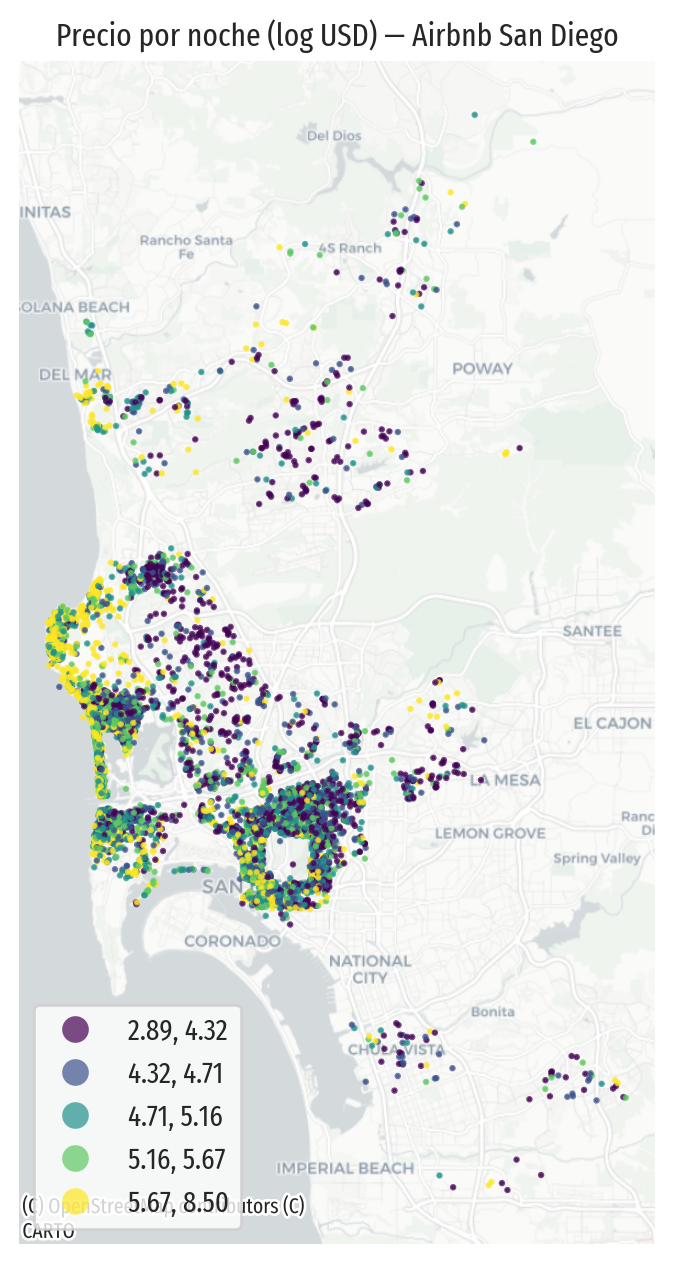

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
db.plot(
    column="log_price", scheme="Quantiles", k=5,
    cmap="viridis", markersize=2, alpha=0.7, ax=ax,
    legend=True, legend_kwds={"fmt": "{:.2f}", "loc": "lower left"},
)
cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Precio por noche (log USD) — Airbnb San Diego", fontsize=12)
plt.savefig("img/clase08/01_mapa_precios.png", dpi=150, bbox_inches="tight")
plt.show()

El patrón es claro: los precios más altos están en la costa (Mission Bay, La Jolla, Pacific Beach) y en zonas céntricas. Hay **estructura espacial** en el precio.

Conceptualmente, el espacio puede entrar a una regresión de dos maneras:

- **Heterogeneidad espacial**: los parámetros del modelo cambian según la zona. Por ejemplo, una habitación extra en La Jolla suma más al precio que la misma habitación en un barrio interior.
- **Dependencia espacial**: las observaciones se *contagian*. El precio de una propiedad depende del precio (o de los atributos) de sus vecinas. Si una zona tiene precios altos, esa influencia se transmite a los vecinos cercanos.

En esta clase nos centraremos en la **dependencia**. La heterogeneidad la veremos en la clase 09 (efectos fijos y regímenes).

## 3. OLS clásico: nuestro punto de partida

Antes de meter el espacio, partamos por lo más sencillo: una **regresión lineal múltiple** estimada por **mínimos cuadrados ordinarios** (OLS, *Ordinary Least Squares*). Es nuestro punto de comparación: queremos saber qué deja sin explicar.

### 3.1 El modelo

Suponemos que la variable a explicar $y_i$ (en nuestro caso `log_price` de la propiedad $i$) es una combinación lineal de $k$ variables explicativas $x_{i1}, \dots, x_{ik}$ más un término de error:

$$
y_i \;=\; \beta_0 \;+\; \beta_1\, x_{i1} \;+\; \beta_2\, x_{i2} \;+\; \cdots \;+\; \beta_k\, x_{ik} \;+\; \varepsilon_i
$$

Lectura de los símbolos:

- $\beta_0$ es el **intercepto**: el valor esperado de $y$ cuando todas las $x$ valen 0.
- $\beta_k$ es el **efecto marginal** de la variable $x_k$: cuánto cambia $y$ en promedio cuando $x_k$ sube en una unidad, *manteniendo el resto constante*.
- $\varepsilon_i$ es el **error**: todo lo que no logramos explicar con las variables disponibles.

Como trabajamos con $\log y$, los coeficientes tienen una lectura cómoda: $\beta_k$ aproxima el **cambio porcentual** en el precio cuando $x_k$ sube en una unidad. Por ejemplo, $\beta_{bedrooms} \approx 0.15$ significa que cada dormitorio adicional sube el precio aproximadamente un 15%.

### 3.2 ¿Cómo elegimos los $\beta$?

OLS los elige minimizando la **suma de los residuos al cuadrado** (SSR):

$$
\hat{\beta} \;=\; \arg\min_{\beta} \;\; \sum_{i=1}^{n} \big(y_i - \hat{y}_i\big)^2
$$

donde $\hat{y}_i = \beta_0 + \sum_k \beta_k x_{ik}$ es el valor predicho y $\hat{u}_i = y_i - \hat{y}_i$ es el **residuo** (la parte que el modelo no captura). En palabras: dibujamos la combinación lineal que pasa lo más cerca posible de todos los puntos, midiendo "cerca" con la distancia vertical al cuadrado. Elevamos al cuadrado para (a) penalizar más los errores grandes y (b) que errores positivos y negativos no se cancelen.

### 3.3 Los supuestos clásicos

Para que las estimaciones de OLS sean **insesgadas, eficientes y con errores estándar válidos** (teorema de Gauss-Markov), se asumen varias cosas sobre los errores $\varepsilon_i$:

1. **Linealidad** del modelo en los parámetros.
2. **Media cero** del error: $E[\varepsilon_i] = 0$.
3. **Homoscedasticidad**: la varianza del error es constante, $\text{Var}(\varepsilon_i) = \sigma^2$.
4. **Independencia** entre errores: $\text{Cov}(\varepsilon_i, \varepsilon_j) = 0$ para $i \neq j$.
5. **No multicolinealidad** perfecta entre las $x$.
6. (Opcional) **Normalidad** de los errores, útil para tests de hipótesis exactos.

El supuesto que va a romperse en datos espaciales — y es la motivación de toda esta clase — es el **(4) Independencia**. Si dos casas vecinas comparten ruido no observado (mismo barrio, misma vista al mar, mismos servicios cercanos), sus errores van a estar correlacionados. Cuando eso ocurre:

- Los $\hat{\beta}$ siguen siendo insesgados, pero **pierden eficiencia**.
- Los **errores estándar se subestiman**, así que damos por significativas variables que no lo son.
- Hay **información espacial** que el modelo no está usando para predecir mejor.

### 3.4 Cómo evaluamos el ajuste

Vamos a usar dos medidas básicas:

- **$R^2$**: proporción de la varianza de $y$ explicada por el modelo. $R^2 = 1 - \frac{SSR}{TSS}$, donde $TSS = \sum_i (y_i - \bar{y})^2$. Va entre 0 y 1; más alto = mejor ajuste.

- **Significancia individual — el p-valor**: cada $\hat{\beta}_k$ trae un **p-valor** asociado, que aparece en la columna `Probability` del output de `spreg.OLS`. Responde la pregunta:

  > *¿Qué tan probable sería ver este $\hat{\beta}_k$ si la variable en realidad no sirviera ($\beta_k = 0$ en la población)?*

  La **regla práctica** es simple:

  - $p < 0.05$ → la variable importa (rechazamos $H_0: \beta_k = 0$).
  - $p > 0.05$ → no podemos distinguir el coeficiente de cero; podría ser azar muestral.

  > **Bonus — el estadístico $t$.** En el output también ves la columna `t-Statistic`, calculada como $t = \hat{\beta}_k / SE(\hat{\beta}_k)$ (señal / ruido). Es el **atajo de cálculo** detrás del p-valor: con $n$ grande, la regla mental es $|t| > 2 \Leftrightarrow p < 0.05$. Si miras el p-valor, ese basta para decidir.

Con eso en mano, ajustemos el modelo:

In [5]:
variables = [
    "accommodates", "bathrooms", "bedrooms", "beds", "d2balboa",
    "rt_Private_room", "rt_Shared_room",
    "pg_Condominium", "pg_House", "pg_Other", "pg_Townhouse",
]

y = db[["log_price"]].values
X = db[variables].values

m1 = spreg.OLS(y, X, name_y="log_price", name_x=variables)
print(m1.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          12
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6098
R-squared           :      0.6685
Adjusted R-squared  :      0.6679
Sum squared residual:     1319.52                F-statistic           :   1117.9338
Sigma-square        :       0.216                Prob(F-statistic)     :           0
S.E. of regression  :       0.465                Log likelihood        :   -3987.446
Sigma-square ML     :       0.216                Akaike info criterion :    7998.892
S.E of regression ML:      0.4647                Schwarz criterion     :    8079.504

-----------------

Algunas lecturas rápidas del resultado:

- `bedrooms` y `accommodates` aportan al precio en la dirección esperada (positiva, significativa).
- `rt_Private_room` y `rt_Shared_room` son negativas: dormir solo en una habitación o compartir abarata frente al `Entire home/apt` (categoría base).
- `d2balboa` es negativo: estar más lejos del parque Balboa reduce el precio.
- El $R^2$ ronda 0.67 — explicamos buena parte de la varianza, pero **no toda**.

Lo que el modelo no nos dice es si esa parte no explicada está **distribuida al azar en el espacio** o si tiene estructura. Eso es lo que vamos a investigar a continuación.

## 4. Diagnóstico: ¿hay estructura espacial en los residuos?

Si el OLS captura toda la señal, los residuos $\hat{u}_i = y_i - \hat{y}_i$ deberían parecerse a ruido blanco repartido al azar en el mapa. Veamos.

Para hacer ese diagnóstico necesitamos dos cosas:

1. **Una matriz de pesos espaciales** $W$ que defina quién es vecino de quién (sin eso, no podemos preguntar nada sobre "el comportamiento de los vecinos").
2. **Los residuos del OLS** guardados como una columna de la tabla, para poder mapearlos y aplicarles Moran's I.

La siguiente celda hace exactamente eso. Voy línea por línea:

### Construir la matriz de vecinos $W$

```python
coords = np.column_stack([db.geometry.x, db.geometry.y])
```
- Cada propiedad en `db` tiene un `POINT` en su columna `geometry`. Sacamos su longitud (`.x`) y latitud (`.y`) y las pegamos en una tabla de 6110 filas × 2 columnas. Es solo **pasar la geometría a una matriz de coordenadas** para que la librería pueda calcular distancias.

```python
w = weights.KNN.from_array(coords, k=20)
```
- **KNN** = *K Nearest Neighbors*. Para cada propiedad, encuentra sus **20 propiedades físicamente más cercanas** y guarda esa relación en la matriz $W$. Por qué k=20: el libro de Rey/Arribas-Bel usa ese valor; es un balance entre "demasiado local" y "demasiado global". Para propiedades (puntos), KNN es la opción estándar — no tenemos polígonos contiguos sobre los que definir vecindad por adyacencia.

```python
w.transform = "r"
```
- **"r" = row-standardize**: hace que cada fila de $W$ sume 1. Pasa de tener 20 unos por fila a tener 20 valores de $\frac{1}{20} = 0.05$. Con esto, cuando calculemos $W \cdot x$ (el "lag espacial" de cualquier variable), obtenemos el **promedio** entre los 20 vecinos, no la suma. El promedio es lo que tiene interpretación natural.

### Guardar los residuos en la tabla

```python
db["residuo_ols"] = m1.u.flatten()
```
- `m1.u` son los residuos del OLS ($\hat{u}_i = y_i - \hat{y}_i$): cuánto se equivocó el modelo en cada propiedad. Vienen como vector columna $(n, 1)$; `.flatten()` los pasa a vector plano $(n,)$ para que `pandas` los acepte como columna nueva.

```python
db["residuo_ols"].describe()
```
- *Sanity check*: imprime count, mean, std, min, max, cuartiles. Verificamos que la media sea $\approx 0$ (siempre cierto si hay intercepto) y que el std cuadre con el `S.E. of regression` del output anterior ($\approx 0.465$).

Al final de la celda tenemos: $W$ (la red de vecinos) + `db["residuo_ols"]` (errores del modelo en cada propiedad). Eso es todo lo que necesitamos para mapear los residuos y testear si tienen autocorrelación espacial.

In [6]:
coords = np.column_stack([db.geometry.x, db.geometry.y])
w = weights.KNN.from_array(coords, k=20)
w.transform = "r"

db["residuo_ols"] = m1.u.flatten()
db["residuo_ols"].describe()

/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


count    6.110000e+03
mean    -5.814589e-16
std      4.647541e-01
min     -1.875312e+00
25%     -2.949932e-01
50%     -4.778531e-02
75%      2.398191e-01
max      3.104174e+00
Name: residuo_ols, dtype: float64

### 4.1 Mapa de residuos

Mapeamos los residuos con paleta divergente centrada en 0: rojo = el modelo subestima (precio observado > predicho), azul = el modelo sobreestima.

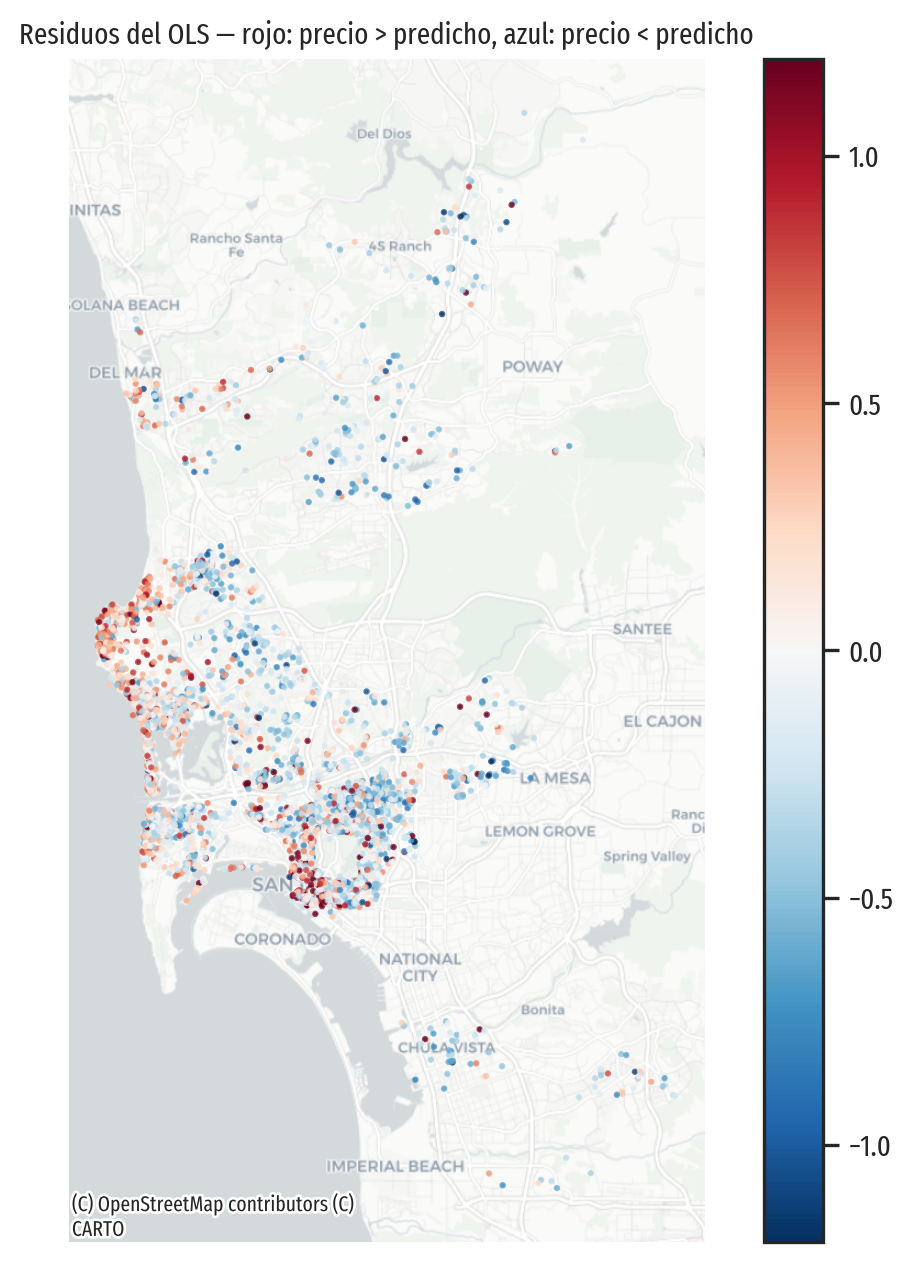

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
lim = db["residuo_ols"].abs().quantile(0.98)  # acotamos extremos para ver mejor
db.plot(
    column="residuo_ols", cmap="RdBu_r",
    vmin=-lim, vmax=lim,
    markersize=2, alpha=0.7, ax=ax, legend=True,
)
cx.add_basemap(ax, crs=db.crs, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title("Residuos del OLS — rojo: precio > predicho, azul: precio < predicho", fontsize=11)
plt.savefig("img/clase08/02_residuos_ols.png", dpi=150, bbox_inches="tight")
plt.show()

El mapa muestra **clusters claros** de signo: zonas enteras donde el modelo sistemáticamente subestima (rojo) y zonas donde sobreestima (azul). Si los errores fueran independientes, no veríamos ese patrón.

### 4.2 Costa vs interior

Una manera simple de cuantificar el sesgo geográfico es comparar los residuos en la costa y fuera de ella.

/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_6616/1325265502.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


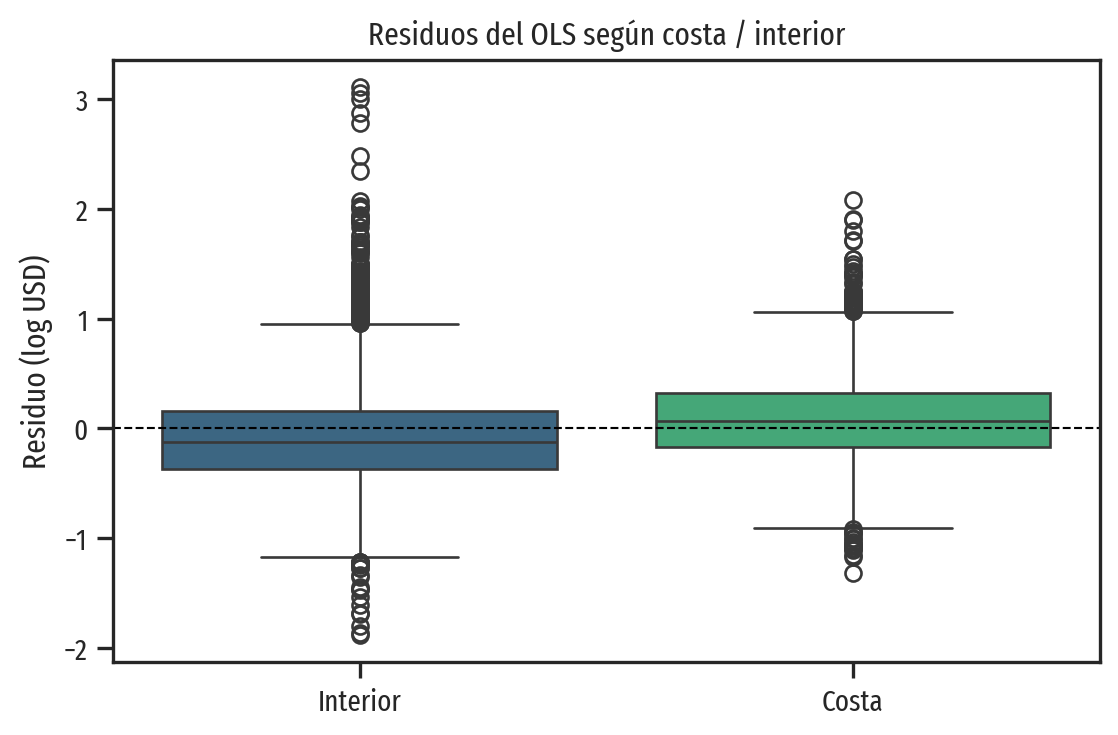

Diferencia de medias costa vs interior: t = 13.26, p = 1.36e-39


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=db.assign(zona=db["coastal"].map({0: "Interior", 1: "Costa"})),
    x="zona", y="residuo_ols", ax=ax, palette="viridis",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Residuos del OLS según costa / interior")
ax.set_xlabel("")
ax.set_ylabel("Residuo (log USD)")
plt.tight_layout()
plt.savefig("img/clase08/03_residuos_costa.png", dpi=150, bbox_inches="tight")
plt.show()

t = ttest_ind(
    db.loc[db["coastal"] == 1, "residuo_ols"],
    db.loc[db["coastal"] == 0, "residuo_ols"],
)
print(f"Diferencia de medias costa vs interior: t = {t.statistic:.2f}, p = {t.pvalue:.2e}")

La media de los residuos en la costa es claramente mayor que en el interior, y la diferencia es altamente significativa. Es decir: **el OLS subestima sistemáticamente** los precios costeros y **sobreestima** los del interior. El modelo está dejando información geográfica sin usar.

### 4.3 Moran's I sobre los residuos

Cuantifiquemos formalmente la autocorrelación espacial de los residuos. Si los errores fueran independientes, Moran's I sería cercano a cero.

In [9]:
mi_ols = Moran(db["residuo_ols"].values, w)
print(f"Moran's I (residuos OLS) = {mi_ols.I:.4f}")
print(f"p-valor (permutaciones)  = {mi_ols.p_sim:.4f}")

Moran's I (residuos OLS) = 0.1411
p-valor (permutaciones)  = 0.0010


Moran's I positivo y significativo: residuos vecinos se parecen entre sí más de lo que cabría esperar por azar. El supuesto de independencia del OLS **no se cumple** en estos datos. Hay que meter el espacio en el modelo.

## 5. SLX: primera forma de incorporar el espacio

La forma más simple — y a menudo la más interpretable — de meter el espacio es agregar como predictores el **lag espacial** de algunas variables explicativas. Esto se llama modelo **SLX** (*Spatial Lag of X*):

$$
\log(P_i) \;=\; \alpha \;+\; \sum_k X_{ik}\, \beta_k \;+\; \sum_k (W X)_{ik}\, \gamma_k \;+\; \varepsilon_i
$$

Donde $(W X)_i$ es el promedio de la variable $X$ entre los vecinos de $i$. Los coeficientes $\gamma_k$ se llaman **efectos de spillover** o **efectos indirectos**: capturan cuánto influye en el precio de $i$ lo que ocurre con sus vecinos.

Por ejemplo, si una propiedad está rodeada de departamentos grandes (alto `accommodates` promedio entre vecinos), eso probablemente indica una zona turística cara y debería empujar su precio hacia arriba, aún manteniendo fijos sus atributos propios.

Calculemos el lag espacial de tres variables clave:

In [10]:
lag_vars = ["accommodates", "bedrooms", "d2balboa"]
for v in lag_vars:
    db[f"w_{v}"] = weights.lag_spatial(w, db[v].values)

db[["accommodates", "w_accommodates", "bedrooms", "w_bedrooms"]].head()

,accommodates,w_accommodates,bedrooms,w_bedrooms
0,5,3.45,2.0,1.30
1,6,5.80,2.0,2.10
2,2,2.80,1.0,1.15
3,2,2.15,1.0,1.10
4,2,4.05,1.0,1.85


Cada `w_<variable>` es el promedio entre los 20 vecinos más cercanos. Ahora ajustamos un OLS extendido con estas nuevas variables:

In [11]:
variables_slx = variables + [f"w_{v}" for v in lag_vars]
X_slx = db[variables_slx].values

m2 = spreg.OLS(y, X_slx, name_y="log_price", name_x=variables_slx)
print(m2.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :   log_price                Number of Observations:        6110
Mean dependent var  :      4.9958                Number of Variables   :          15
S.D. dependent var  :      0.8072                Degrees of Freedom    :        6095
R-squared           :      0.6871
Adjusted R-squared  :      0.6864
Sum squared residual:     1245.49                F-statistic           :    956.0055
Sigma-square        :       0.204                Prob(F-statistic)     :           0
S.E. of regression  :       0.452                Log likelihood        :   -3811.052
Sigma-square ML     :       0.204                Akaike info criterion :    7652.105
S.E of regression ML:      0.4515                Schwarz criterion     :    7752.870

-----------------

Lo que vale la pena observar:

- El coeficiente de `w_accommodates` es **positivo y significativo**: estar rodeado de propiedades grandes encarece la mía, incluso si la mía es pequeña.
- `w_d2balboa` tiende a captar el efecto de zona céntrica vs periférica de los vecinos.
- Los coeficientes de las variables originales se ajustan ligeramente: parte de lo que antes atribuíamos a la propiedad ahora se atribuye al entorno.

Verifiquemos si el SLX limpió la dependencia espacial en los residuos:

In [12]:
db["residuo_slx"] = m2.u.flatten()
mi_slx = Moran(db["residuo_slx"].values, w)
print(f"Moran's I residuos SLX = {mi_slx.I:.4f} (p = {mi_slx.p_sim:.4f})")
print(f"Moran's I residuos OLS = {mi_ols.I:.4f} (p = {mi_ols.p_sim:.4f})  ← comparación")

Moran's I residuos SLX = 0.1048 (p = 0.0010)
Moran's I residuos OLS = 0.1411 (p = 0.0010)  ← comparación


Moran's I baja, pero **sigue siendo positivo y significativo**. El SLX captura parte de la estructura espacial — la que viene de los atributos de los vecinos — pero queda dependencia sin explicar. ¿De dónde viene?

## 6. Comparación y cierre

Resumamos los dos modelos:

In [13]:
resumen = pd.DataFrame({
    "R²":              [m1.r2,        m2.r2],
    "# variables":     [len(variables), len(variables_slx)],
    "Moran I residuos":[mi_ols.I,     mi_slx.I],
    "p-valor Moran":   [mi_ols.p_sim, mi_slx.p_sim],
}, index=["OLS", "SLX"]).round(4)
resumen

,R²,# variables,Moran I residuos,p-valor Moran
OLS,0.6685,11,0.1411,0.001
SLX,0.6871,14,0.1048,0.001


Lo que aprendimos:

1. Un OLS ingenuo sobre datos espaciales suele dejar **estructura geográfica sistemática en los residuos**. Verlo es la diferencia entre confiar y no confiar en el modelo.
2. El **mapa de residuos** y **Moran's I** son las dos herramientas básicas para detectar ese problema.
3. El modelo **SLX** es la forma más directa y más interpretable de incorporar el espacio: agregamos el promedio de los vecinos como variable explicativa. Captura los **spillovers exógenos** (cómo influyen los *atributos* del entorno).
4. Pero el SLX **no resuelve todo**: la autocorrelación residual baja pero no desaparece. Hay dependencia que no viene de los atributos observados de los vecinos.

### Lo que viene en la clase 09

Quedan dos formas más profundas — y más sutiles — de meter el espacio:

- **Modelo de error espacial (SEM)**: la dependencia está en el **término de error**. Variables omitidas (que sí están espacialmente correlacionadas) explican lo que sobra. Estimamos $\lambda$, el parámetro de autocorrelación del error.
- **Modelo de lag espacial (SAR)**: el precio de una propiedad depende del **precio** (no de los atributos) de sus vecinas. El proceso es **endógeno**: $\log(P_i) = \rho \sum_j w_{ij} \log(P_j) + X\beta + \varepsilon$. Esto requiere métodos de estimación distintos a OLS (variables instrumentales / GMM).

También exploraremos **heterogeneidad** (efectos fijos por barrio, regímenes costa/interior) e **interpretación de efectos directos vs indirectos**.

## Para profundizar

- Rey, S., Arribas-Bel, D. & Wolf, L. J. (2020). *Geographic Data Science with Python*, Capítulo 11.
- Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic Publishers.
- LeSage, J. & Pace, R. K. (2009). *Introduction to Spatial Econometrics*. CRC Press.